# MNIST: PCA vs Autoencoder

Comparing classical PCA against a neural autoencoder for dimensionality reduction on handwritten digits. This notebook is part of my MATH 415 Capstone shows visual reconstructions, eigendigits, and 2D projections that show what each method is actually learning.

**Sections:**
1. Setup & data loading
2. PCA — eigendigits, scree plot, reconstruction sweep
3. Autoencoder — training, reconstruction, side-by-side comparison
4. 2D projections + timing/error summary

## 1. Setup & Data Loading

In [4]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

import keras
keras.utils.set_random_seed(42)

# Paper-quality matplotlib defaults
plt.rcParams.update({
    'figure.dpi': 110,        # screen rendering
    'savefig.dpi': 300,       # saved files
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'image.cmap': 'gray',
})

print('Setup complete.')

Setup complete.


In [5]:
# Figure-saving helper — writes BOTH PDF (for LaTeX) and PNG (for previews) at 300 DPI
FIG_DIR = Path('figures/mnist')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, fig=None) -> None:
    """Save the current (or given) figure as both PDF and PNG into figures/mnist/."""
    fig = fig or plt.gcf()
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'{name}.{ext}')
    print(f'  saved -> {FIG_DIR}/{name}.{{pdf,png}}')

print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: C:\Users\berez\Documents\github\PCA\figures\mnist


In [6]:
# Load MNIST (28x28 = 784 dimensions). First run downloads ~55MB and caches.
print('Loading MNIST from openml (cached after first run)...')
t0 = time.time()
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data.astype(np.float32) / 255.0   # normalize to [0, 1]
y_full = mnist.target.astype(int)
print(f'  loaded {X_full.shape[0]} images in {time.time() - t0:.1f}s')

# Subsample to 10,000 images (stratified so all 10 digits stay roughly balanced)
rng = np.random.default_rng(42)
idx_per_class = [rng.choice(np.where(y_full == d)[0], size=1000, replace=False) for d in range(10)]
idx = np.concatenate(idx_per_class)
rng.shuffle(idx)

X = X_full[idx]
y = y_full[idx]
print(f'\nSubsampled dataset:')
print(f'  X shape: {X.shape}    (n_samples, n_features)')
print(f'  y shape: {y.shape}')
print(f'  pixel range: [{X.min():.2f}, {X.max():.2f}]')
print(f'  class counts: {np.bincount(y)}')

Loading MNIST from openml (cached after first run)...
  loaded 70000 images in 7.8s

Subsampled dataset:
  X shape: (10000, 784)    (n_samples, n_features)
  y shape: (10000,)
  pixel range: [0.00, 1.00]
  class counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


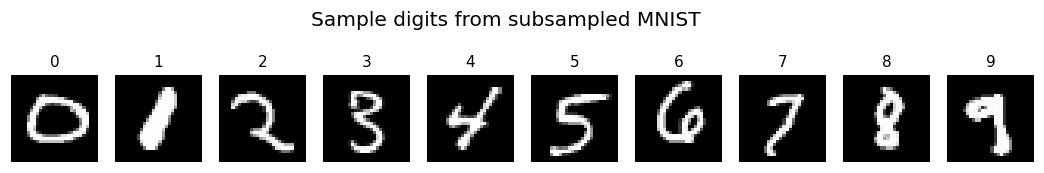

In [7]:
# Sanity check — display 10 random digits, one per class
fig, axes = plt.subplots(1, 10, figsize=(12, 1.5))
for d, ax in enumerate(axes):
    sample_idx = np.where(y == d)[0][0]
    ax.imshow(X[sample_idx].reshape(28, 28))
    ax.set_title(f'{d}', fontsize=10)
    ax.axis('off')
fig.suptitle('Sample digits from subsampled MNIST', y=1.15)
plt.show()

## 2. PCA:  Eigendigits, Scree Plot, Reconstruction Sweep

PCA finds the orthogonal directions of maximum variance in the data. Each principal component is itself a 784-dim vector (the same shape as a digit), so we can visualize them directly as 28×28 images — the famous "eigendigits".

In [8]:
from sklearn.decomposition import PCA

# Fit PCA on all 784 components so we can reconstruct at any depth
print('Fitting PCA on full 784 components...')
t0 = time.time()
pca_full = PCA(n_components=784, random_state=42).fit(X)
pca_time = time.time() - t0
print(f'  done in {pca_time:.2f}s')

# Cumulative variance — needed for the scree plot annotations
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
k_90 = int(np.searchsorted(cum_var, 0.90)) + 1
k_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f'  components for 90% variance: {k_90}')
print(f'  components for 95% variance: {k_95}')

Fitting PCA on full 784 components...
  done in 0.55s
  components for 90% variance: 86
  components for 95% variance: 152


### Figure 1: Eigendigits (first 10 principal components)

  saved -> figures\mnist/fig1_eigendigits.{pdf,png}


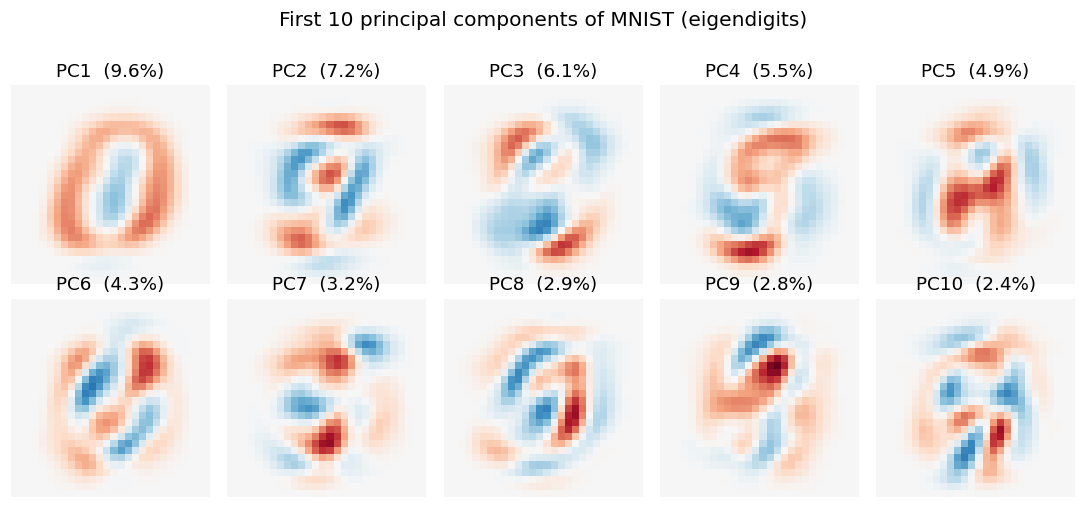

In [9]:
# Diverging colormap with symmetric range so positive/negative weights are both visible
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
vmax = np.abs(pca_full.components_[:10]).max()
for i, ax in enumerate(axes.flat):
    pc = pca_full.components_[i].reshape(28, 28)
    ax.imshow(pc, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    var_pct = pca_full.explained_variance_ratio_[i] * 100
    ax.set_title(f'PC{i+1}  ({var_pct:.1f}%)')
    ax.axis('off')
fig.suptitle('First 10 principal components of MNIST (eigendigits)', y=1.02)
plt.tight_layout()
save_fig('fig1_eigendigits')
plt.show()

### Figure 2: Scree plot (variance explained)

  saved -> figures\mnist/fig2_scree.{pdf,png}


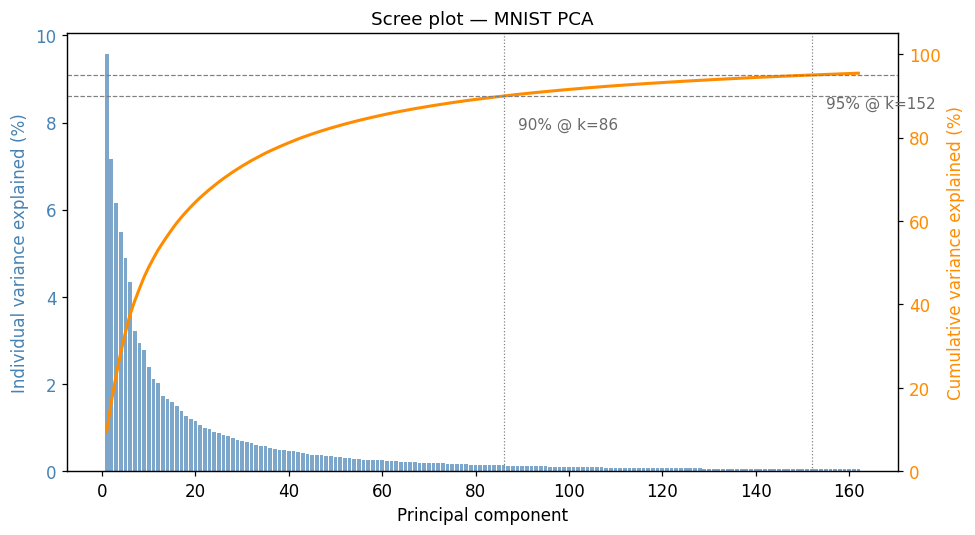

In [10]:
# Show enough components to comfortably include the 95% threshold
n_show = max(50, k_95 + 10)
x_axis = np.arange(1, n_show + 1)
indiv = pca_full.explained_variance_ratio_[:n_show] * 100
cum = cum_var[:n_show] * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x_axis, indiv, color='steelblue', alpha=0.7, label='Individual variance')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Individual variance explained (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(x_axis, cum, color='darkorange', linewidth=2, label='Cumulative variance')
ax2.set_ylabel('Cumulative variance explained (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 105)

# Mark 90% and 95% thresholds
for thresh, k in [(90, k_90), (95, k_95)]:
    ax2.axhline(thresh, color='gray', linestyle='--', linewidth=0.8)
    ax2.axvline(k, color='gray', linestyle=':', linewidth=0.8)
    ax2.annotate(f'{thresh}% @ k={k}', xy=(k, thresh),
                 xytext=(k + 3, thresh - 8), fontsize=10,
                 color='dimgray')

ax1.set_title('Scree plot — MNIST PCA')
plt.tight_layout()
save_fig('fig2_scree')
plt.show()

### Figure 3 Reconstruction (PCA)

A single test digit reconstructed using progressively more components. With 5 PCs you barely see a shape, by 50 PCs the digit is clearly readable, at 784 (the full dimensionality) reconstruction is exact.

  saved -> figures\mnist/fig3_pca_reconstruction_sweep.{pdf,png}


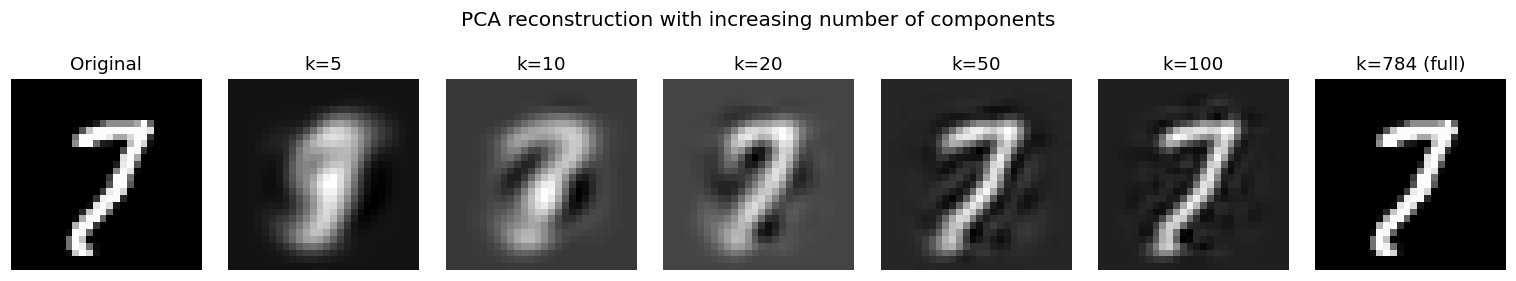

In [11]:
def pca_reconstruct(x_flat: np.ndarray, k: int) -> np.ndarray:
    """Reconstruct a single 784-d image using only the first k principal components."""
    centered = x_flat - pca_full.mean_
    z = centered @ pca_full.components_[:k].T          # project: 784 -> k
    return z @ pca_full.components_[:k] + pca_full.mean_   # back-project: k -> 784

# Pick one sample digit (use class 7 — has clean curves that show degradation well)
SAMPLE_IDX = np.where(y == 7)[0][0]
sample = X[SAMPLE_IDX]
ks = [5, 10, 20, 50, 100, 784]

fig, axes = plt.subplots(1, len(ks) + 1, figsize=(2 * (len(ks) + 1), 2.4))
axes[0].imshow(sample.reshape(28, 28))
axes[0].set_title('Original')
axes[0].axis('off')
for ax, k in zip(axes[1:], ks):
    recon = pca_reconstruct(sample, k)
    ax.imshow(recon.reshape(28, 28))
    label = 'k=784 (full)' if k == 784 else f'k={k}'
    ax.set_title(label)
    ax.axis('off')
fig.suptitle('PCA reconstruction with increasing number of components', y=1.05)
plt.tight_layout()
save_fig('fig3_pca_reconstruction_sweep')
plt.show()

## 3. Autoencoder: Build, Train, Reconstruct

A neural autoencoder learns nonlinear projections by squeezing the input through a bottleneck layer. We use the same latent dimensionality as one of the PCA values (k=20) so the comparison is fair.

**Architecture:** 784 → 256 → 128 → 64 → 20 → 64 → 128 → 256 → 784, ReLU activations, sigmoid output (since pixels are in [0, 1]), MSE loss.

In [12]:
from keras import layers, Model, Input

LATENT_DIM = 20   # same dim used for PCA comparison

def build_autoencoder(latent_dim: int):
    inp = Input(shape=(784,), name='input')
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    x = layers.Dense(64, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(784, activation='sigmoid', name='output')(x)

    autoencoder = Model(inp, out, name=f'autoencoder_d{latent_dim}')
    encoder = Model(inp, z, name=f'encoder_d{latent_dim}')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(LATENT_DIM)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "autoencoder_d20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,588 (1.86 MB)

 Trainable params: 487,588 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train — 50 epochs, batch 256, 10% validation split for monitoring
print(f'Training autoencoder (latent_dim={LATENT_DIM})...')
t0 = time.time()
history = autoencoder.fit(
    X, X,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
)
ae_train_time = time.time() - t0
print()
print(f'Training done in {ae_train_time:.1f}s')
print(f'Final train MSE: {history.history["loss"][-1]:.5f}')
print(f'Final val   MSE: {history.history["val_loss"][-1]:.5f}')

Training autoencoder (latent_dim=20)...
Epoch 1/50
36/36 - 3s - 88ms/step - loss: 0.1178 - val_loss: 0.0750
Epoch 2/50
36/36 - 0s - 12ms/step - loss: 0.0723 - val_loss: 0.0706
Epoch 3/50
36/36 - 0s - 12ms/step - loss: 0.0652 - val_loss: 0.0598
Epoch 4/50
36/36 - 0s - 12ms/step - loss: 0.0542 - val_loss: 0.0495
Epoch 5/50
36/36 - 0s - 13ms/step - loss: 0.0460 - val_loss: 0.0424
Epoch 6/50
36/36 - 0s - 11ms/step - loss: 0.0403 - val_loss: 0.0379
Epoch 7/50
36/36 - 0s - 12ms/step - loss: 0.0367 - val_loss: 0.0365
Epoch 8/50
36/36 - 0s - 12ms/step - loss: 0.0345 - val_loss: 0.0334
Epoch 9/50
36/36 - 0s - 12ms/step - loss: 0.0324 - val_loss: 0.0315
Epoch 10/50
36/36 - 0s - 12ms/step - loss: 0.0304 - val_loss: 0.0297
Epoch 11/50
36/36 - 0s - 12ms/step - loss: 0.0288 - val_loss: 0.0284
Epoch 12/50
36/36 - 0s - 12ms/step - loss: 0.0277 - val_loss: 0.0279
Epoch 13/50
36/36 - 0s - 12ms/step - loss: 0.0266 - val_loss: 0.0285
Epoch 14/50
36/36 - 0s - 13ms/step - loss: 0.0261 - val_loss: 0.0259
Epo

### Training curve

  saved -> figures\mnist/fig_ae_training_curve.{pdf,png}


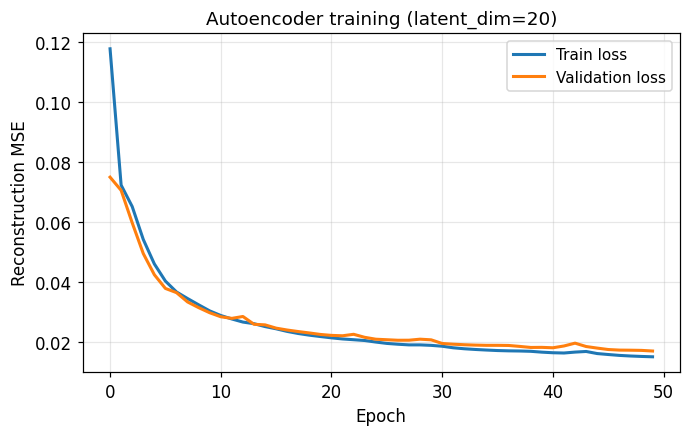

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'], label='Train loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction MSE')
ax.set_title(f'Autoencoder training (latent_dim={LATENT_DIM})')
ax.legend()
ax.grid(alpha=0.3)
save_fig('fig_ae_training_curve')
plt.show()

### Figure 4 — AE vs PCA reconstruction of the same digit (latent_dim=20)

The autoencoder gets the same number of latent dimensions (20) as PCA, so any difference in reconstruction quality reflects the value of nonlinearity, not extra capacity.

  saved -> figures\mnist/fig4_pca_vs_ae_single_digit.{pdf,png}


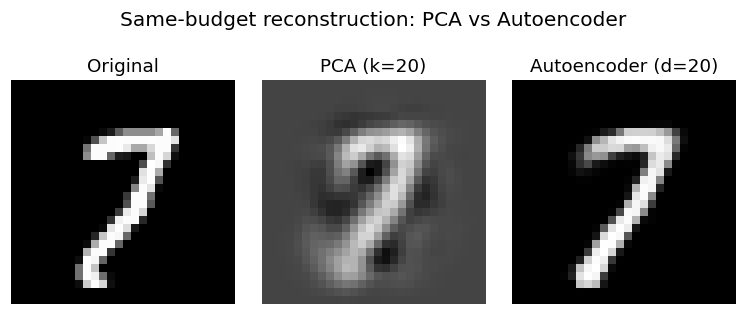

In [15]:
# Reconstruct the SAME sample digit (the 7) with both methods at latent_dim=20
sample_2d = sample.reshape(1, 784)
ae_recon = autoencoder.predict(sample_2d, verbose=0)[0]
pca_recon = pca_reconstruct(sample, LATENT_DIM)

fig, axes = plt.subplots(1, 3, figsize=(7, 2.7))
for ax, img, title in zip(
    axes,
    [sample, pca_recon, ae_recon],
    ['Original', f'PCA (k={LATENT_DIM})', f'Autoencoder (d={LATENT_DIM})'],
):
    ax.imshow(img.reshape(28, 28))
    ax.set_title(title)
    ax.axis('off')
fig.suptitle('Same-budget reconstruction: PCA vs Autoencoder', y=1.05)
plt.tight_layout()
save_fig('fig4_pca_vs_ae_single_digit')
plt.show()

### Figure 5  Reconstruction grid 

One row of 10 different digits, original vs PCA vs AE, at the same latent dimension. This is the headline figure showing how the two methods compare across all digits

  saved -> figures\mnist/fig5_reconstruction_grid.{pdf,png}


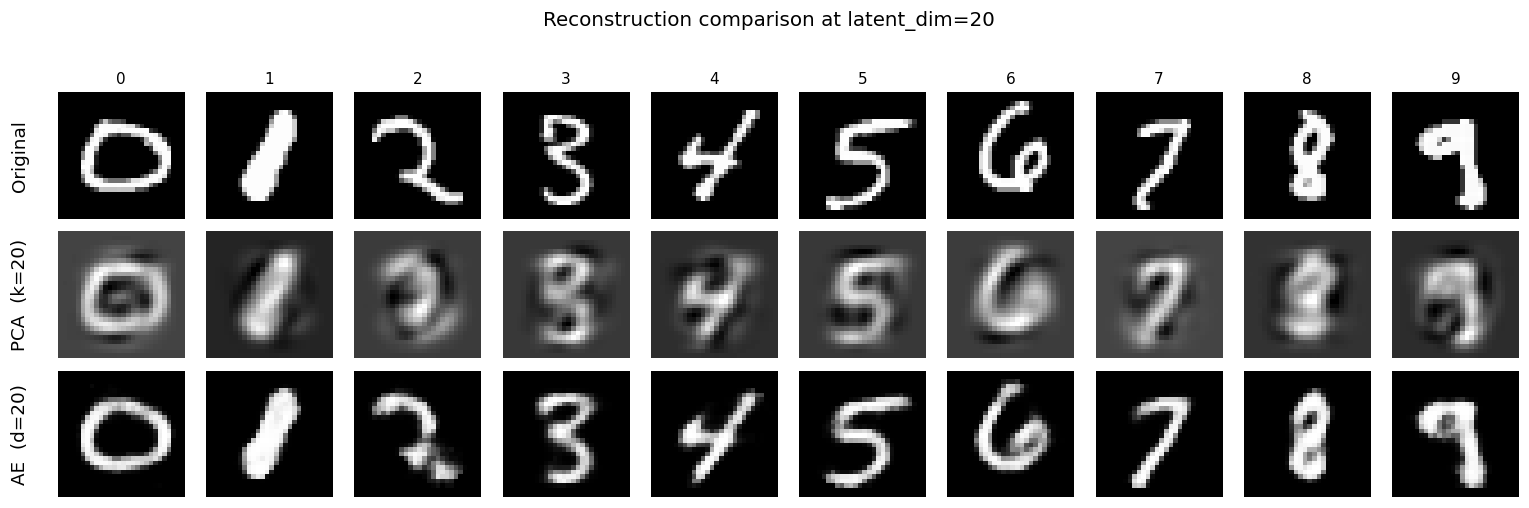

In [16]:
# Pick one example per class for diversity
grid_idx = np.array([np.where(y == d)[0][0] for d in range(10)])
originals = X[grid_idx]                                    # (10, 784)
pca_recons = np.stack([pca_reconstruct(x, LATENT_DIM) for x in originals])
ae_recons = autoencoder.predict(originals, verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(14, 4.5))
row_data = [originals, pca_recons, ae_recons]
row_labels = ['Original', f'PCA  (k={LATENT_DIM})', f'AE  (d={LATENT_DIM})']

for row, (data, label) in enumerate(zip(row_data, row_labels)):
    for col in range(10):
        ax = axes[row, col]
        ax.imshow(data[col].reshape(28, 28))
        ax.axis('off')
        if col == 0:
            ax.text(-0.3, 0.5, label, transform=ax.transAxes,
                    rotation=90, ha='center', va='center', fontsize=12)
        if row == 0:
            ax.set_title(f'{col}', fontsize=10)

fig.suptitle(f'Reconstruction comparison at latent_dim={LATENT_DIM}', y=1.02, fontsize=13)
plt.tight_layout()
save_fig('fig5_reconstruction_grid')
plt.show()

## 4. Comparison: 2D Projections, MSE, Timing

The reconstruction grid shows AE wins at moderate dimensions. Now we ask a different question: when forced down to **just 2 dimensions** for visualization, how well does each method preserve the *class structure* of the digits?

### Train a separate autoencoder with latent_dim=2

In [17]:
# A new autoencoder squeezed all the way down to 2D
ae_2d, encoder_2d = build_autoencoder(latent_dim=2)
ae_2d.compile(optimizer='adam', loss='mse')

print('Training 2D-bottleneck autoencoder...')
t0 = time.time()
hist_2d = ae_2d.fit(
    X, X,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
)
ae_2d_train_time = time.time() - t0
print()
print(f'Done in {ae_2d_train_time:.1f}s. Final val MSE: {hist_2d.history["val_loss"][-1]:.5f}')

Training 2D-bottleneck autoencoder...
Epoch 1/50
36/36 - 3s - 78ms/step - loss: 0.1211 - val_loss: 0.0755
Epoch 2/50
36/36 - 0s - 11ms/step - loss: 0.0732 - val_loss: 0.0727
Epoch 3/50
36/36 - 0s - 13ms/step - loss: 0.0698 - val_loss: 0.0675
Epoch 4/50
36/36 - 0s - 12ms/step - loss: 0.0655 - val_loss: 0.0634
Epoch 5/50
36/36 - 0s - 12ms/step - loss: 0.0607 - val_loss: 0.0587
Epoch 6/50
36/36 - 0s - 12ms/step - loss: 0.0571 - val_loss: 0.0561
Epoch 7/50
36/36 - 0s - 12ms/step - loss: 0.0553 - val_loss: 0.0546
Epoch 8/50
36/36 - 0s - 12ms/step - loss: 0.0540 - val_loss: 0.0536
Epoch 9/50
36/36 - 0s - 12ms/step - loss: 0.0531 - val_loss: 0.0527
Epoch 10/50
36/36 - 0s - 12ms/step - loss: 0.0523 - val_loss: 0.0521
Epoch 11/50
36/36 - 0s - 12ms/step - loss: 0.0517 - val_loss: 0.0518
Epoch 12/50
36/36 - 0s - 12ms/step - loss: 0.0512 - val_loss: 0.0512
Epoch 13/50
36/36 - 0s - 12ms/step - loss: 0.0508 - val_loss: 0.0508
Epoch 14/50
36/36 - 0s - 11ms/step - loss: 0.0504 - val_loss: 0.0504
Epoch

### Figure 6 — 2D projections side-by-side

Same 10,000 digits, projected to 2D by each method, colored by class label. Overlap between classes = the method has folded distinct digits onto each other; clean clusters = the method preserves class structure.

  saved -> figures\mnist/fig6_2d_projections.{pdf,png}


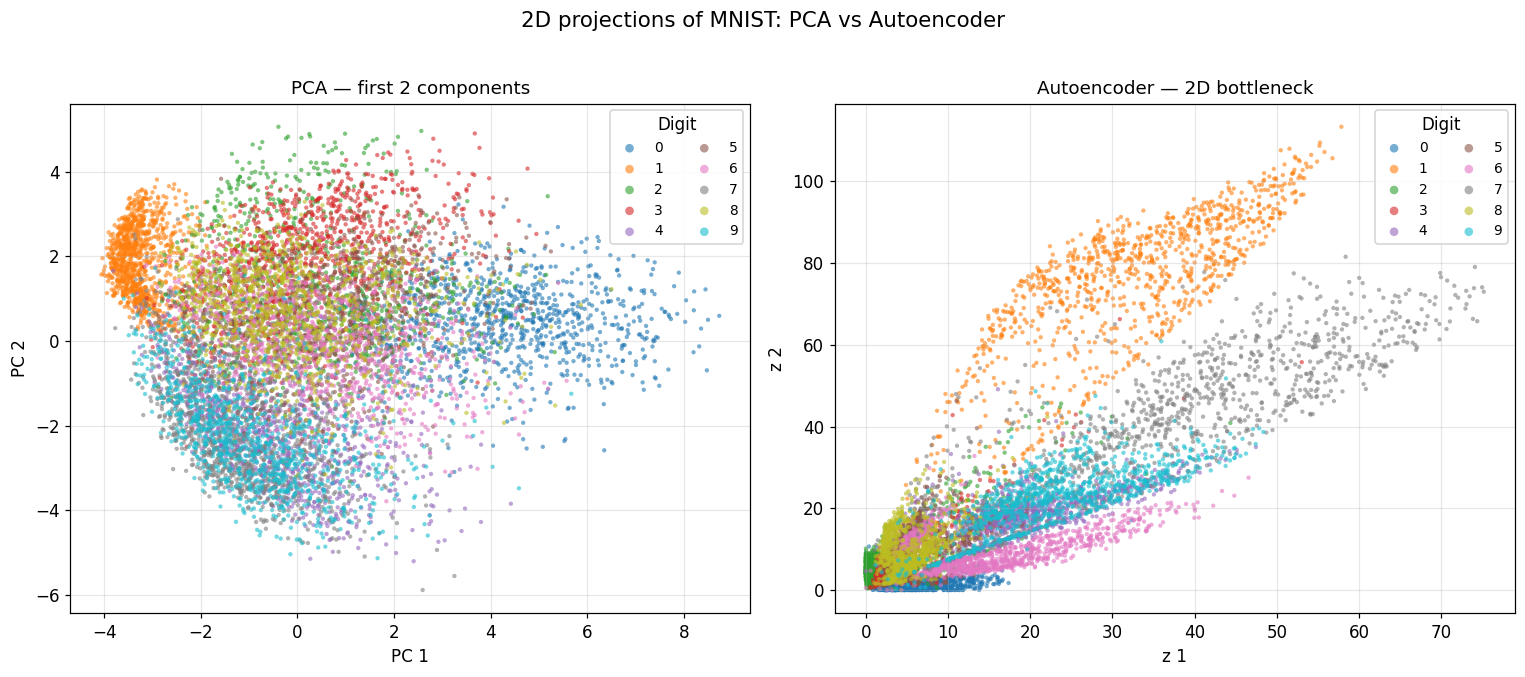

In [18]:
# Compute both 2D embeddings
pca_2d_proj = pca_full.transform(X)[:, :2]
ae_2d_proj = encoder_2d.predict(X, verbose=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.tab10

for digit in range(10):
    mask = (y == digit)
    color = [cmap(digit)]
    ax1.scatter(pca_2d_proj[mask, 0], pca_2d_proj[mask, 1],
                c=color, s=8, alpha=0.6, label=str(digit), edgecolors='none')
    ax2.scatter(ae_2d_proj[mask, 0], ae_2d_proj[mask, 1],
                c=color, s=8, alpha=0.6, label=str(digit), edgecolors='none')

ax1.set_title('PCA — first 2 components')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')

ax2.set_title('Autoencoder — 2D bottleneck')
ax2.set_xlabel('z 1')
ax2.set_ylabel('z 2')

for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
    ax.legend(title='Digit', loc='best', fontsize=9, markerscale=2,
              ncol=2, framealpha=0.85)

fig.suptitle('2D projections of MNIST: PCA vs Autoencoder', y=1.02, fontsize=14)
plt.tight_layout()
save_fig('fig6_2d_projections')
plt.show()

### Figure 7 / Table: Reconstruction MSE and Timing

Final quantitative comparison at the same latent dimension (d=20). PCA's "training" is a single SVD, while the autoencoder requires gradient descent so PCA wins on time by orders of magnitude. The interesting question is whether AE wins on reconstruction quality enough to justify the computational cost.

In [19]:
# Vectorized PCA reconstruction over the full dataset
def pca_reconstruct_batch(X_batch: np.ndarray, k: int) -> np.ndarray:
    centered = X_batch - pca_full.mean_
    z = centered @ pca_full.components_[:k].T
    return z @ pca_full.components_[:k] + pca_full.mean_

pca_recon_all = pca_reconstruct_batch(X, LATENT_DIM)
pca_mse = float(np.mean((X - pca_recon_all) ** 2))

ae_recon_all = autoencoder.predict(X, verbose=0)
ae_mse = float(np.mean((X - ae_recon_all) ** 2))

print(f'PCA  reconstruction MSE  (k={LATENT_DIM}): {pca_mse:.5f}')
print(f'AE   reconstruction MSE  (d={LATENT_DIM}): {ae_mse:.5f}')
print(f'AE / PCA MSE ratio: {ae_mse / pca_mse:.3f}    (lower = AE is better)')

PCA  reconstruction MSE  (k=20): 0.02395
AE   reconstruction MSE  (d=20): 0.01519
AE / PCA MSE ratio: 0.634    (lower = AE is better)


In [20]:
import pandas as pd

results = pd.DataFrame([
    {'Method': 'PCA',         'Latent Dim': LATENT_DIM, 'Reconstruction MSE': pca_mse, 'Time (s)': pca_time},
    {'Method': 'Autoencoder', 'Latent Dim': LATENT_DIM, 'Reconstruction MSE': ae_mse,  'Time (s)': ae_train_time},
])

print('=' * 60)
print('SUMMARY — MNIST  (10,000 samples, latent_dim=20)')
print('=' * 60)
print(results.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
print('=' * 60)

# Save table for the paper
results.to_csv(FIG_DIR / 'summary_table.csv', index=False)
print(f'  saved -> {FIG_DIR}/summary_table.csv')

SUMMARY — MNIST  (10,000 samples, latent_dim=20)
     Method  Latent Dim  Reconstruction MSE  Time (s)
        PCA          20             0.02395   0.54936
Autoencoder          20             0.01519  25.08949
  saved -> figures\mnist/summary_table.csv


  saved -> figures\mnist/fig7_summary_bars.{pdf,png}


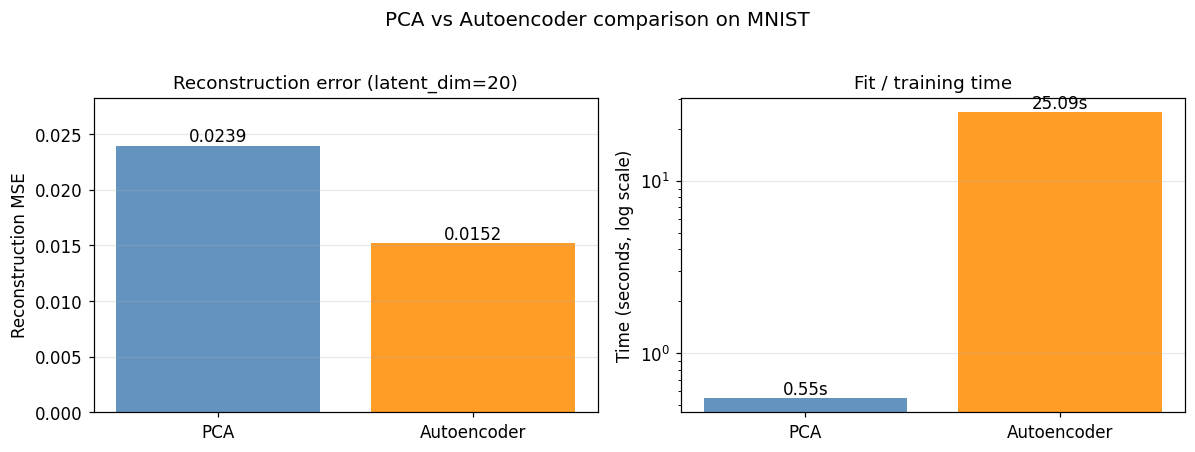

In [28]:
# Visual version of the summary table — nice to drop into a paper as Figure 7
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

methods = ['PCA', 'Autoencoder']
mses = [pca_mse, ae_mse]
times = [pca_time, ae_train_time]
colors = ['steelblue', 'darkorange']

bars1 = ax1.bar(methods, mses, color=colors, alpha=0.85)
ax1.set_ylabel('Reconstruction MSE')
ax1.set_title(f'Reconstruction error (latent_dim={LATENT_DIM})')
for b, v in zip(bars1, mses):
    ax1.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}',
             ha='center', va='bottom', fontsize=11)
ax1.set_ylim(0, max(mses) * 1.18)
ax1.grid(alpha=0.3, axis='y')

bars2 = ax2.bar(methods, times, color=colors, alpha=0.85)
ax2.set_ylabel('Time (seconds, log scale)')
ax2.set_yscale('log')
ax2.set_title('Fit / training time')
for b, v in zip(bars2, times):
    ax2.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}s',
             ha='center', va='bottom', fontsize=11)
ax2.grid(alpha=0.3, axis='y')

fig.suptitle('PCA vs Autoencoder comparison on MNIST', y=1.02, fontsize=13)
plt.tight_layout()
save_fig('fig7_summary_bars')
plt.show()

## 5. Sanity Check — Linear Autoencoder = PCA

There's a known theoretical result: **a linear autoencoder (no nonlinear activations) trained with MSE loss learns the same subspace as PCA.** The two methods produce identical reconstructions, even though the autoencoder is trained by gradient descent and PCA by SVD.

Why this matters :
1. **It validates our implementation.** If our linear AE converges to PCA's MSE, both pipelines are correct.
2. **It isolates the contribution of nonlinearity.** Any improvement the ReLU autoencoder achieves over PCA is therefore attributable *specifically* to the nonlinear activations not architectural capacity, not the optimizer, not training data.

We use a **single-bottleneck linear AE** (784 → 20 → 784, no activations) for clarity. The architecture is mathematically the simplest version of the claim. With a deep linear AE the result still holds, just slower to converge.

In [22]:
def build_linear_autoencoder(latent_dim: int):
    """Single-bottleneck linear autoencoder. No activations anywhere."""
    inp = Input(shape=(784,), name='input')
    z   = layers.Dense(latent_dim, activation='linear', name='latent')(inp)
    out = layers.Dense(784,        activation='linear', name='output')(z)
    autoencoder = Model(inp, out, name=f'linear_autoencoder_d{latent_dim}')
    encoder     = Model(inp, z,   name=f'linear_encoder_d{latent_dim}')
    return autoencoder, encoder

linear_ae, linear_encoder = build_linear_autoencoder(LATENT_DIM)
linear_ae.compile(optimizer='adam', loss='mse')
linear_ae.summary()

Model: "linear_autoencoder_d20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 784)            │        16,464 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,164 (125.64 KB)

 Trainable params: 32,164 (125.64 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print('Training linear autoencoder (no activations)...')
t0 = time.time()
hist_lin = linear_ae.fit(
    X, X,
    epochs=100,           # linear AEs need more epochs to converge tightly
    batch_size=256,
    validation_split=0.1,
    verbose=2,
)
linear_ae_time = time.time() - t0
print()
print(f'Done in {linear_ae_time:.1f}s')
print(f'Final train MSE: {hist_lin.history["loss"][-1]:.5f}')
print(f'Final val   MSE: {hist_lin.history["val_loss"][-1]:.5f}')

Training linear autoencoder (no activations)...
Epoch 1/100
36/36 - 1s - 31ms/step - loss: 0.0879 - val_loss: 0.0645
Epoch 2/100
36/36 - 0s - 8ms/step - loss: 0.0593 - val_loss: 0.0542
Epoch 3/100
36/36 - 0s - 7ms/step - loss: 0.0493 - val_loss: 0.0452
Epoch 4/100
36/36 - 0s - 8ms/step - loss: 0.0423 - val_loss: 0.0398
Epoch 5/100
36/36 - 0s - 8ms/step - loss: 0.0380 - val_loss: 0.0364
Epoch 6/100
36/36 - 0s - 8ms/step - loss: 0.0349 - val_loss: 0.0335
Epoch 7/100
36/36 - 0s - 7ms/step - loss: 0.0322 - val_loss: 0.0311
Epoch 8/100
36/36 - 0s - 7ms/step - loss: 0.0302 - val_loss: 0.0294
Epoch 9/100
36/36 - 0s - 7ms/step - loss: 0.0286 - val_loss: 0.0280
Epoch 10/100
36/36 - 0s - 8ms/step - loss: 0.0275 - val_loss: 0.0270
Epoch 11/100
36/36 - 0s - 7ms/step - loss: 0.0266 - val_loss: 0.0263
Epoch 12/100
36/36 - 0s - 7ms/step - loss: 0.0259 - val_loss: 0.0257
Epoch 13/100
36/36 - 0s - 7ms/step - loss: 0.0255 - val_loss: 0.0253
Epoch 14/100
36/36 - 0s - 10ms/step - loss: 0.0251 - val_loss: 

### Compare reconstruction MSE — three methods at the same latent dim

In [24]:
linear_ae_recon_all = linear_ae.predict(X, verbose=0)
linear_ae_mse = float(np.mean((X - linear_ae_recon_all) ** 2))

comparison = pd.DataFrame([
    {'Method': 'PCA',              'Latent Dim': LATENT_DIM, 'MSE': pca_mse,       'Nonlinear?': 'No'},
    {'Method': 'Linear AE',        'Latent Dim': LATENT_DIM, 'MSE': linear_ae_mse, 'Nonlinear?': 'No'},
    {'Method': 'ReLU AE (sigmoid out)', 'Latent Dim': LATENT_DIM, 'MSE': ae_mse,    'Nonlinear?': 'Yes'},
])

print('=' * 65)
print('RECONSTRUCTION MSE COMPARISON  (MNIST, latent_dim=20)')
print('=' * 65)
print(comparison.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
print('=' * 65)
print()
print(f'|PCA MSE - Linear AE MSE| = {abs(pca_mse - linear_ae_mse):.6f}')
print(f'  (small number = confirms theoretical equivalence)')
print()
print(f'ReLU AE improvement over PCA:        {(1 - ae_mse/pca_mse)*100:.1f}% lower MSE')
print(f'ReLU AE improvement over Linear AE:  {(1 - ae_mse/linear_ae_mse)*100:.1f}% lower MSE')
print(f'  (this improvement is attributable to nonlinearity alone)')

comparison.to_csv(FIG_DIR / 'linear_ae_comparison.csv', index=False)

RECONSTRUCTION MSE COMPARISON  (MNIST, latent_dim=20)
               Method  Latent Dim     MSE Nonlinear?
                  PCA          20 0.02395         No
            Linear AE          20 0.02399         No
ReLU AE (sigmoid out)          20 0.01519        Yes

|PCA MSE - Linear AE MSE| = 0.000047
  (small number = confirms theoretical equivalence)

ReLU AE improvement over PCA:        36.6% lower MSE
ReLU AE improvement over Linear AE:  36.7% lower MSE
  (this improvement is attributable to nonlinearity alone)


### Figure 8  Linear AE reconstruction is visually identical to PCA

The same sample digit reconstructed by all three methods. PCA and Linear-AE should be **indistinguishable**; ReLU-AE should be noticeably sharper than both.

  saved -> figures\mnist/fig8_linear_ae_vs_pca.{pdf,png}


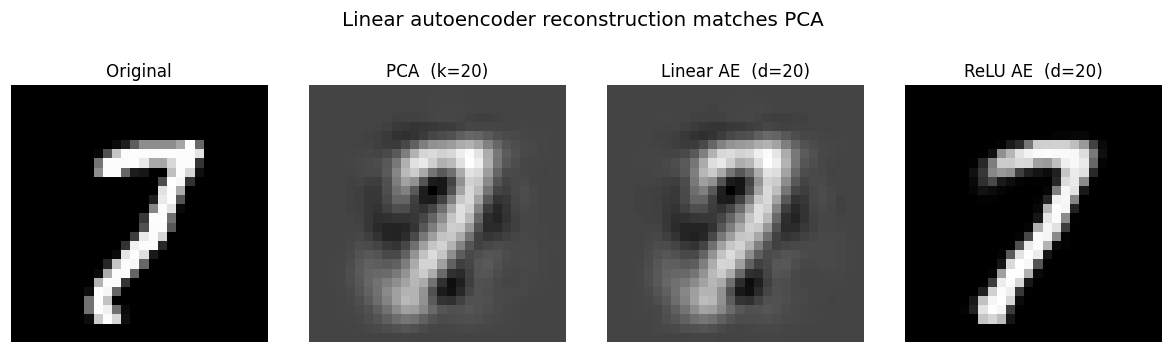

Per-sample agreement (PCA vs Linear AE on the test digit):
  L2 distance         : 0.19287
  Max pixel difference: 0.03143


In [26]:
sample_2d = sample.reshape(1, 784)
pca_recon_sample        = pca_reconstruct(sample, LATENT_DIM)
linear_ae_recon_sample  = linear_ae.predict(sample_2d, verbose=0)[0]
relu_ae_recon_sample    = autoencoder.predict(sample_2d, verbose=0)[0]

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
imgs   = [sample, pca_recon_sample, linear_ae_recon_sample, relu_ae_recon_sample]
titles = ['Original', f'PCA  (k={LATENT_DIM})', f'Linear AE  (d={LATENT_DIM})', f'ReLU AE  (d={LATENT_DIM})']
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img.reshape(28, 28))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
fig.suptitle('Linear autoencoder reconstruction matches PCA ', y=1.06, fontsize=13)
plt.tight_layout()
save_fig('fig8_linear_ae_vs_pca')
plt.show()

# Quantify how close PCA and Linear AE actually are, pixel-by-pixel
l2_pca_vs_linae = float(np.linalg.norm(pca_recon_sample - linear_ae_recon_sample))
max_pixel_diff  = float(np.max(np.abs(pca_recon_sample - linear_ae_recon_sample)))
print(f'Per-sample agreement (PCA vs Linear AE on the test digit):')
print(f'  L2 distance         : {l2_pca_vs_linae:.5f}')
print(f'  Max pixel difference: {max_pixel_diff:.5f}')

### Subspace equivalence — proving they project onto the same 20-D plane

If the linear AE learns the same *subspace* as PCA (regardless of basis rotation), then projecting the entire dataset through both should produce **identical reconstructions** for every sample, not just the test one. We measure the average per-pixel disagreement across all 10,000 digits.

In [ ]:
# Across the whole dataset: how often do PCA and Linear-AE disagree?
diff_all = pca_recon_all - linear_ae_recon_all
mean_abs_diff = float(np.mean(np.abs(diff_all)))
mean_sq_diff  = float(np.mean(diff_all ** 2))

print('Whole-dataset agreement between PCA and Linear AE reconstructions:')
print(f'  Mean absolute pixel difference : {mean_abs_diff:.6f}')
print(f'  Mean squared pixel difference  : {mean_sq_diff:.6f}')
print()
print(f'For reference, pixel values are in [0, 1].')
print(f'A difference below ~0.01 means the two methods agree to within ~1% per pixel,')
print(f'i.e. their learned subspaces are numerically the same.')